# 11. Generalized Regression Neural Network (GRNN)
**Algorithm implemented:** Specht's GRNN (Nadaraya-Watson kernel regression) from scratch.

**Dataset:** real motorcycle accelerometer data (`data/motorcycle.csv`, R `MASS::mcycle`): time after impact vs head acceleration.


In [1]:
# ---- Core libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)


## GRNN Architecture

### Step-by-Step Algorithm (Generalized Regression Neural Network)
1. **Input layer:** receive the d-dimensional query vector x and pass it to every pattern neuron.
2. **Pattern layer:** with N training points, each unit i computes a Gaussian activation p_i(x) = exp(−||x − x_i||² / (2σ²)).
3. **Summation layer:** compute two sums over all pattern units:
   - S(x) = Σ_i y_i · p_i(x)  (weighted by training targets)
   - D(x) = Σ_i p_i(x)        (normalization)
4. **Output layer:** predict the conditional mean ŷ(x) = S(x) / D(x) (Nadaraya-Watson estimator).
5. **Training:** one pass - just store the training set; **no** backpropagation or iterative optimization.
6. **Tuning:** only σ must be chosen (small σ = memorizes noise; large σ = over-smooth).

In [2]:
class GRNN(BaseEstimator, RegressorMixin):
    """
    Generalized Regression Neural Network (Specht, 1991) - vectorized implementation.

    Prediction is the Nadaraya-Watson kernel regression estimate:
        y_hat(x) = sum_i y_i * exp(-||x - x_i||^2 / (2*sigma^2))
                 / sum_i     exp(-||x - x_i||^2 / (2*sigma^2))

    Training is one-pass: the model simply stores the training set (no gradient descent).
    The only hyperparameter is the smoothing spread sigma.
    """

    def __init__(self, sigma=1.0):
        self.sigma = sigma

    def fit(self, X, y):
        # "Training" = memorizing the data (pattern + summation layers)
        self.X_train_ = np.asarray(X, dtype=np.float64)
        self.y_train_ = np.asarray(y, dtype=np.float64).ravel()
        return self

    def predict(self, X):
        X_test = np.asarray(X, dtype=np.float64)

        # ---- Pattern layer: squared Euclidean distance between each test and train point ----
        # Uses the expansion ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a.b for efficiency.
        dist_sq = np.sum(X_test**2, axis=1, keepdims=True) + \
                  np.sum(self.X_train_**2, axis=1, keepdims=True).T - \
                  2 * np.dot(X_test, self.X_train_.T)
        dist_sq = np.maximum(dist_sq, 0.0)  # guard against tiny negative values from rounding

        # ---- Pattern layer activation: Gaussian kernel of each training point ----
        kernels = np.exp(-dist_sq / (2.0 * (self.sigma ** 2)))

        # ---- Summation layer: D-sum (denominator) and S-sum (numerator) ----
        D = np.sum(kernels, axis=1)                 # unweighted sum of activations
        S = np.dot(kernels, self.y_train_)          # activation-weighted sum of targets

        # ---- Output layer: normalized weighted average (prevents 0/0 for isolated queries) ----
        D_safe = np.where(D < 1e-12, 1e-12, D)
        return S / D_safe


print("Custom vectorized GRNN class defined!")


Custom vectorized GRNN class defined!


## Smoothing Parameter σ

### The Role of the Smoothing Parameter σ
1. Fit GRNNs with a small, medium and large σ on the same noisy 1D data.
2. Small σ (0.05): each training point dominates its own neighborhood -> wiggly curve, high variance.
3. Large σ (1.50): all points influence every query -> flat curve, high bias.
4. Medium σ (≈0.35): smooth interpolation that follows the true underlying function.
5. Compare training R² and curve shapes to see the bias-variance trade-off.

### Hyperparameter Optimization Process (5-Fold CV)
1. Define a grid of candidate σ values from 0.05 to 1.0.
2. Split the data into 5 fixed folds.
3. For each σ: fit on 4 folds, compute RMSE on the held-out fold, then average the 5 scores.
4. Select the σ with the lowest average CV RMSE.
5. Plot the CV error curve to confirm a clear optimum.

Motorcycle data: 133 observations | time 2.4-57.6 ms | accel -134 to 75 g


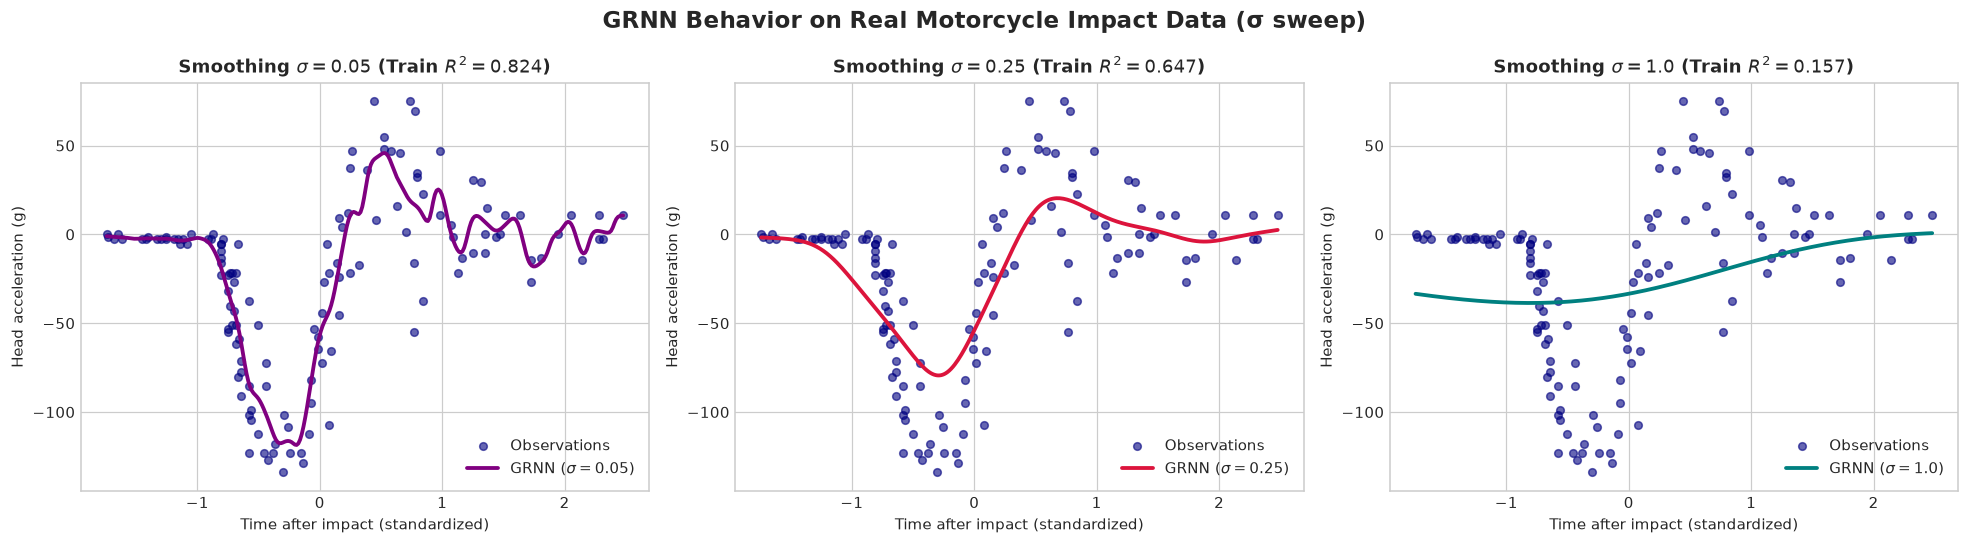

In [3]:
# ---- Load the real motorcycle impact data (MASS::mcycle) ----
moto = pd.read_csv('../data/motorcycle.csv')
X = StandardScaler().fit_transform(moto['times'].values.reshape(-1, 1))  # time after impact (scaled)
y = moto['accel'].values                                                 # head acceleration (g)
print(f"Motorcycle data: {len(moto)} observations | time {moto.times.min()}-{moto.times.max()} ms | accel {moto.accel.min():.0f} to {moto.accel.max():.0f} g")

X_eval = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# Under-smoothing, near-optimal, over-smoothing
sigmas = [0.05, 0.25, 1.0]
colors = ['purple', 'crimson', 'teal']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sig, col in zip(axes, sigmas, colors):
    # Fit a fresh GRNN for each sigma (training is instant)
    grnn_demo = GRNN(sigma=sig).fit(X, y)
    y_pred_demo = grnn_demo.predict(X_eval)

    ax.scatter(X, y, color='navy', s=25, alpha=0.6, label='Observations')
    ax.plot(X_eval, y_pred_demo, color=col, lw=2.5, label=rf'GRNN ($\sigma={sig}$)')

    # Training R² shows the bias-variance behavior for each sigma
    r2 = r2_score(y, grnn_demo.predict(X))
    ax.set_title(rf"Smoothing $\sigma = {sig}$ (Train $R^2 = {r2:.3f}$)", fontweight='bold')
    ax.set_xlabel("Time after impact (standardized)")
    ax.set_ylabel("Head acceleration (g)")
    ax.legend(loc='lower right')

plt.suptitle("GRNN Behavior on Real Motorcycle Impact Data (σ sweep)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


Optimal Smoothing Parameter σ: 0.080 (CV RMSE: 25.0023 g)


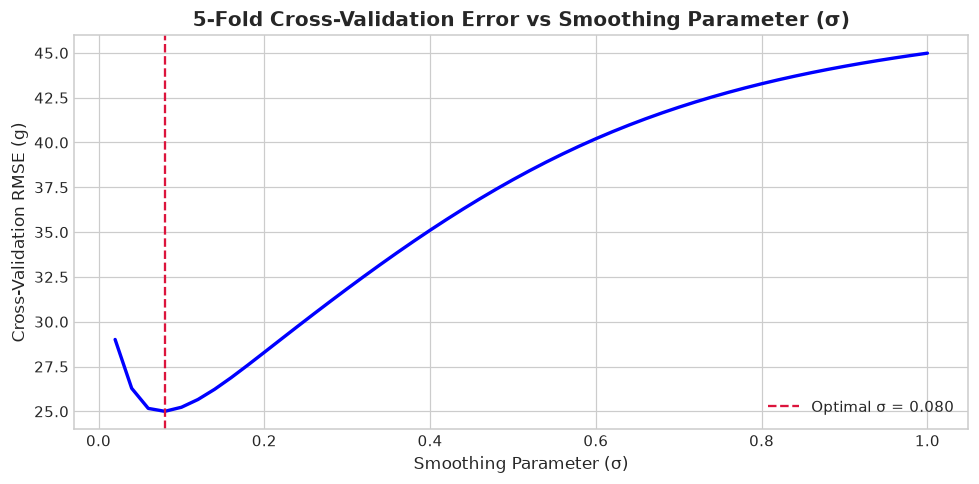

In [4]:
# ---- 5-fold CV grid search for the optimal smoothing sigma ----
sigma_candidates = np.linspace(0.02, 1.0, 50)
cv_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)   # fixed folds for a fair comparison

for sig in sigma_candidates:
    fold_rmses = []
    for train_idx, val_idx in kf.split(X):
        # Split the data into this fold's train/validation parts
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_va, y_va = X[val_idx], y[val_idx]

        # Fit GRNN on the training fold and score on the validation fold
        model = GRNN(sigma=sig).fit(X_tr, y_tr)
        preds = model.predict(X_va)
        fold_rmses.append(root_mean_squared_error(y_va, preds))

    cv_scores.append(np.mean(fold_rmses))   # average CV error for this sigma

best_idx = np.argmin(cv_scores)
best_sigma = sigma_candidates[best_idx]
print(f"Optimal Smoothing Parameter σ: {best_sigma:.3f} (CV RMSE: {cv_scores[best_idx]:.4f} g)")

# ---- Plot the CV error curve and mark the optimum ----
plt.figure(figsize=(9, 4.5))
plt.plot(sigma_candidates, cv_scores, 'b-', lw=2.2)
plt.axvline(x=best_sigma, color='crimson', linestyle='--', label=f'Optimal σ = {best_sigma:.3f}')
plt.title("5-Fold Cross-Validation Error vs Smoothing Parameter (σ)", fontsize=13, fontweight='bold')
plt.xlabel("Smoothing Parameter (σ)", fontsize=11)
plt.ylabel("Cross-Validation RMSE (g)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# ---- Final model: refit with the CV-selected sigma and evaluate on a held-out split ----
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
final_model = GRNN(sigma=best_sigma).fit(X_tr, y_tr)
y_hat = final_model.predict(X_te)

print(f"Final GRNN with CV-selected sigma = {best_sigma:.3f}")
print(f" - Train R²:  {r2_score(y_tr, final_model.predict(X_tr)):.4f}")
print(f" - Test R²:   {r2_score(y_te, y_hat):.4f}")
print(f" - Test RMSE: {root_mean_squared_error(y_te, y_hat):.4f} g")


Final GRNN with CV-selected sigma = 0.080
 - Train R²:  0.8073
 - Test R²:   0.7255
 - Test RMSE: 22.7760 g
